In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = pd.read_csv("data/dataset.csv")
n_cols = 3
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   person_id          682 non-null    int64  
 1   article_id         682 non-null    int64  
 2   age                618 non-null    float64
 3   gender             581 non-null    object 
 4   severity           661 non-null    object 
 5   is_driver          678 non-null    object 
 6   vehicle_type       568 non-null    object 
 7   person_state       17 non-null     object 
 8   accident_id        682 non-null    float64
 9   date_time          682 non-null    object 
 10  accident_type      682 non-null    object 
 11  location           643 non-null    object 
 12  temperature_2m     682 non-null    float64
 13  precipitation      682 non-null    float64
 14  windspeed_10m      682 non-null    float64
 15  cloud_cover        682 non-null    float64
 16  weather_code       682 non

In [5]:
df.head()

,person_id,article_id,age,gender,severity,is_driver,vehicle_type,person_state,accident_id,date_time,...,windspeed_10m,cloud_cover,weather_code,is_weekday,is_public_holiday,time_of_day,month,hour,day,year
0,0,4208,78.0,male,none,True,car,NaN,0.0,2024-12-04 17:00:00,...,9.8,100.0,3.0,True,False,evening,12,17.0,4,2024
1,1,4093,54.0,male,serious,True,motorcycle,NaN,1.0,2024-12-11 17:00:00,...,6.5,100.0,3.0,True,False,evening,12,17.0,11,2024
2,2,4110,54.0,male,serious,True,motorcycle,NaN,2.0,2024-12-11 13:00:00,...,5.0,97.0,3.0,True,False,afternoon,12,13.0,11,2024
3,3,4066,17.0,female,serious,False,NaN,NaN,3.0,2024-12-13 17:30:00,...,24.0,2.0,0.0,True,False,evening,12,17.5,13,2024
4,4,4066,52.0,male,none,True,car,NaN,3.0,2024-12-13 17:30:00,...,24.0,2.0,0.0,True,False,evening,12,17.5,13,2024


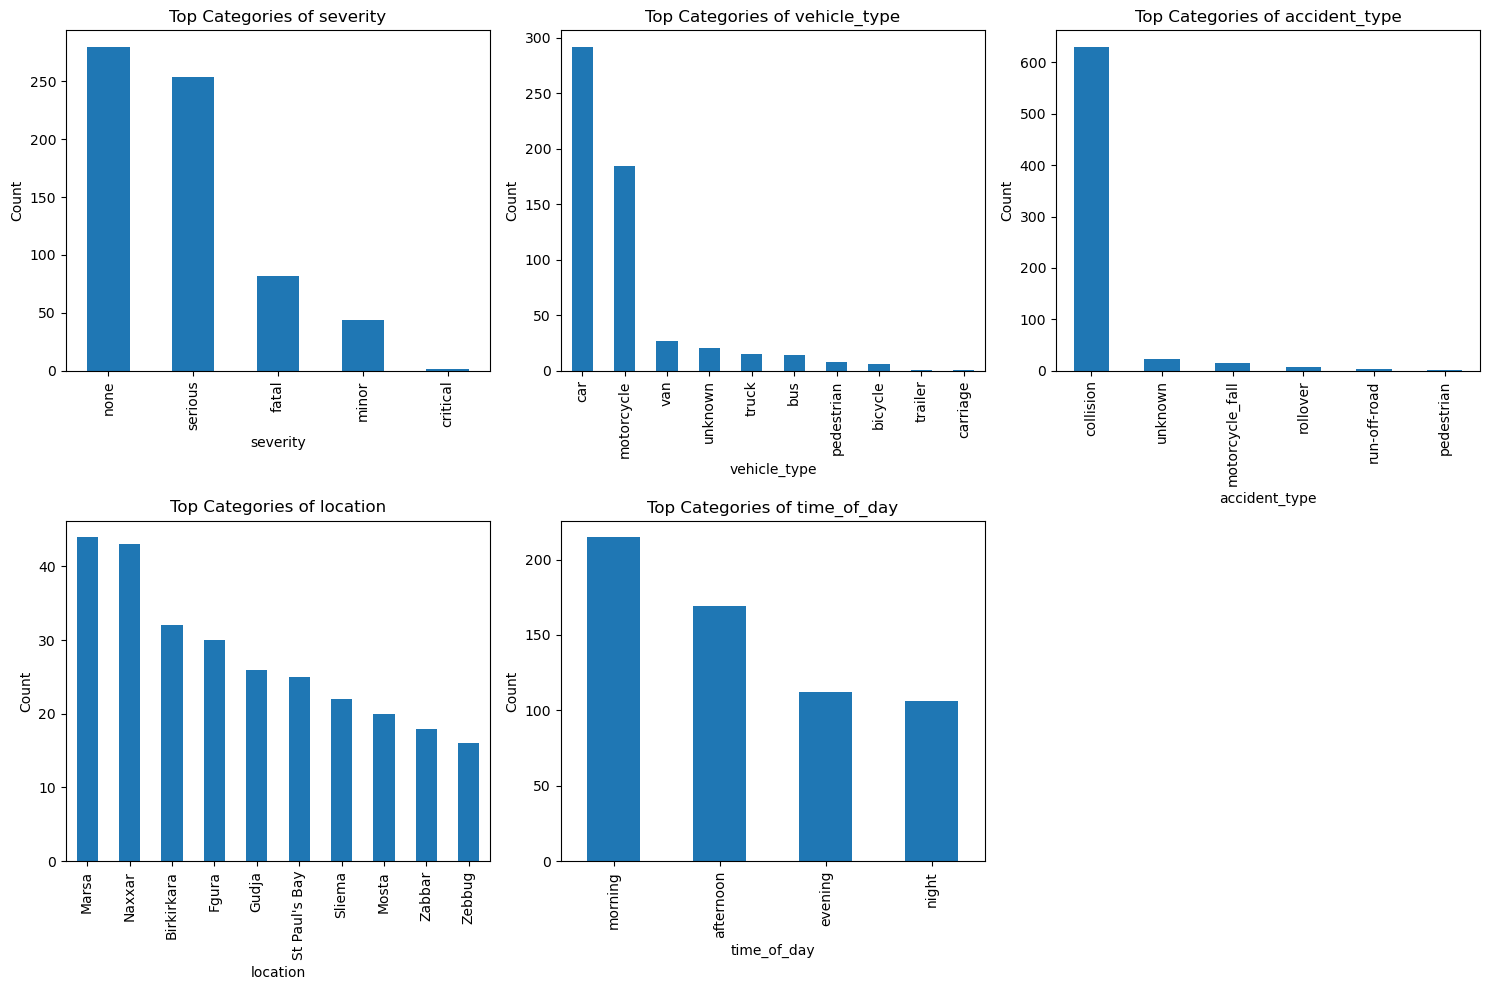

In [2]:
categorical_cols = ["severity", "vehicle_type", "accident_type", "location", "time_of_day"]
# for col in categorical_cols:
#     print(f"\n{col}")
#     print(df[col].value_counts(dropna=False).head(10))
    
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().head(10).plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"Top Categories of {col}")
    # axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    
# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

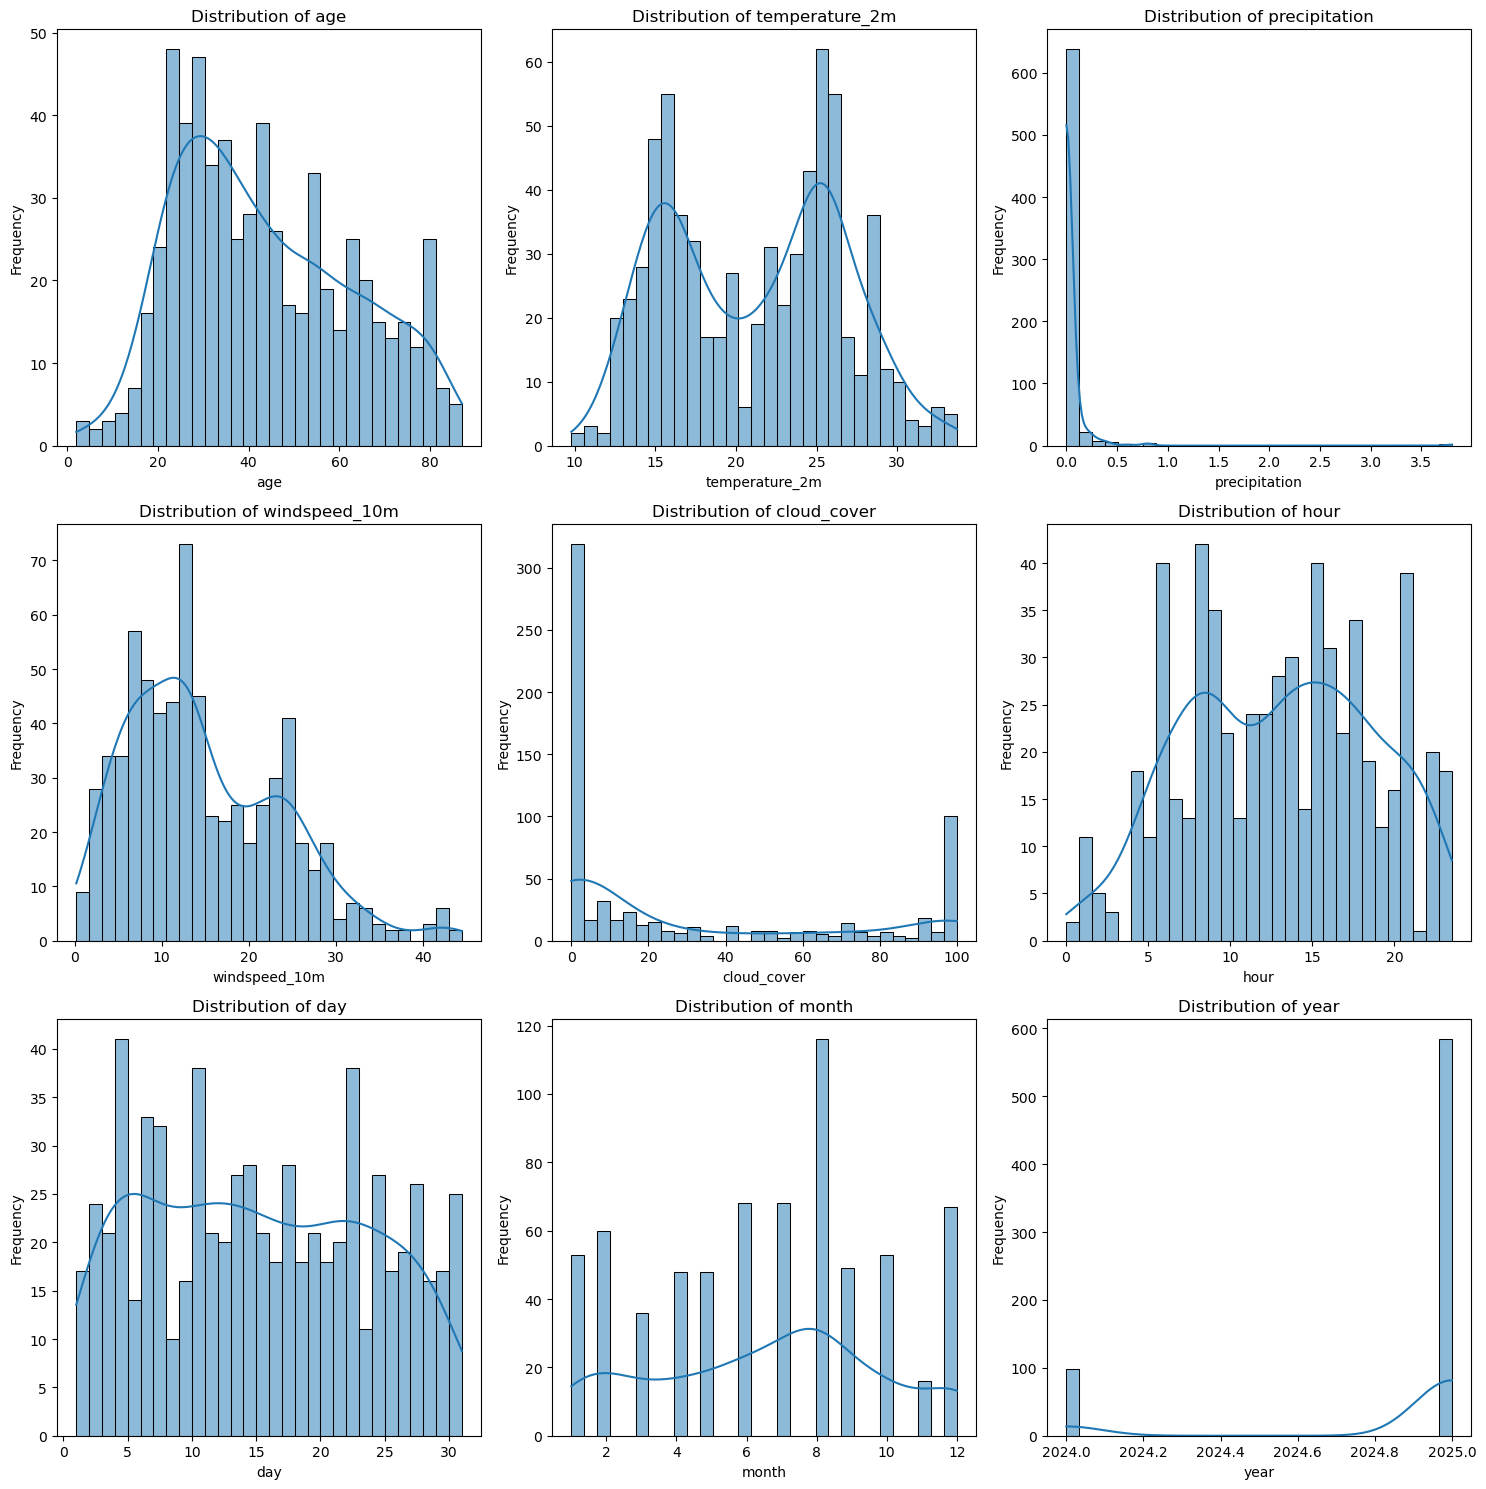

In [3]:
numerical_cols = ["age", "temperature_2m", "precipitation", "windspeed_10m", "cloud_cover", "hour", "day", "month", "year"]

n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    
# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
n_cols = math.ceil(len(numerical_cols) / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x="severity", y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Severity")
    
# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

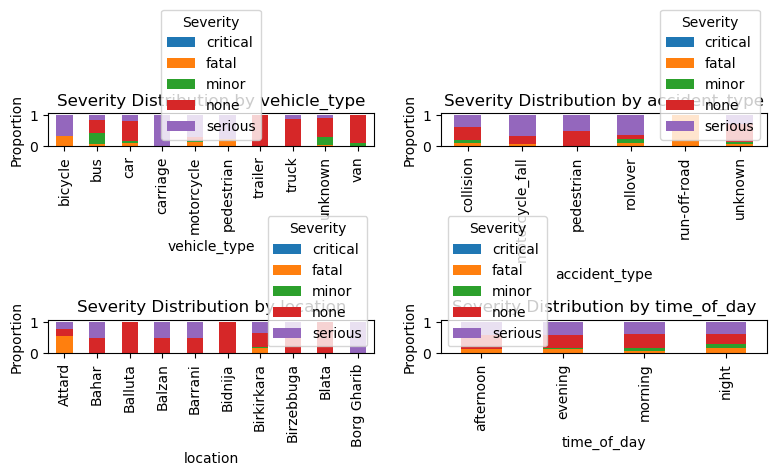

In [4]:
categorical_cols_excluding_severity = [col for col in categorical_cols if col != "severity"]

n_cols = math.ceil(len(categorical_cols_excluding_severity) / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_excluding_severity):
    prop_df = pd.crosstab(df[col], df["severity"], normalize="index").head(10)

    prop_df.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 5),
        ax=axes[i]
    )

    axes[i].set_title(f"Severity Distribution by {col}")
    axes[i].set_ylabel("Proportion")
    axes[i].set_xlabel(col)
    axes[i].legend(title="Severity")
    
# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()